# Chapter 20 — Pulsar Timing Arrays & Nanohertz Gravitational Waves

!!! info "Before you start"
    **Prerequisites:** Ch 13 (Pulsars) · **Maths Lab:** none · **~50 min** · **Advanced**

In **Chapter 13** we met the **pulsar** — a rotating, magnetised neutron star
whose beam sweeps past us like a lighthouse — and learned to *de-disperse* and
*fold* its pulses into a clean profile. We closed by noting, in one paragraph,
that the average profile is a **template** for **pulsar timing**: measuring the
arrival time of each pulse to better than a microsecond and fitting a model that
predicts every future arrival.

This chapter takes that one paragraph and turns it into a gravitational-wave
detector. A single **millisecond pulsar** (MSP) is one of the most stable clocks
in the Universe. An **array** of MSPs scattered across the sky — a **Pulsar
Timing Array** (PTA) — is a galaxy-sized gravitational-wave antenna, sensitive to
waves with periods of *years* (nanohertz frequencies) radiated by merging
**supermassive black-hole binaries**. The signature that distinguishes a
gravitational-wave background from a mere clock error is a specific, quadrupolar
pattern in how the timing residuals of *pairs* of pulsars correlate with the
angle between them: the **Hellings–Downs curve**. In 2023 several PTAs reported
the first compelling evidence of exactly that curve.

### Learning goals

By the end of this chapter you will be able to:

- explain why a **millisecond pulsar** is a precision clock, and what a timing
  **residual** is;
- describe the **PTA idea** (Foster & Backer 1990) — why an *array* of pulsars
  across the sky is a nanohertz gravitational-wave detector — and name the major
  PTAs and the 2023 result;
- write down and plot the **Hellings–Downs curve** $\Gamma(\theta)$, and explain
  its shape and why it is the fingerprint of a gravitational-wave background, as
  opposed to a **monopole** (clock) or **dipole** (ephemeris) error;
- **simulate** an array of pulsars with an HD-correlated common signal plus white
  noise, and **recover** the Hellings–Downs curve from the pairwise correlations
  — the NANOGrav 2023 result in miniature;
- appreciate why a low-SNR or few-pulsar array leaves the curve *buried*, and how
  PTAs complement LIGO and LISA at far lower frequencies.

Everything runs **offline** on the base environment, using the
`jansky.timing` helpers. No network, no optional extras.

## 1. Orientation — a clock, an array, and a 2023 announcement

### A millisecond pulsar is a clock

Most pulsars spin once every $\sim 0.1$–$1$ s and slow down measurably. A
**millisecond pulsar** spins hundreds of times per second — periods of a few
milliseconds — and slows down *extraordinarily* slowly. These are old neutron
stars that were **"recycled"**: spun up by accreting matter from a binary
companion. The first was discovered by

> **Backer, D. C., Kulkarni, S. R., Heiles, C., Davis, M. M. & Goss, W. M.
> (1982).** *A millisecond pulsar.* **Nature 300, 615.**
> [ADS](https://ui.adsabs.harvard.edu/abs/1982Natur.300..615B)

PSR B1937+21 spins **642 times a second** ($P \approx 1.558$ ms). Its rotation is
so stable that, after fitting a timing model, the pulse arrival times can be
predicted to **tens of nanoseconds** over years — rivalling the best atomic
clocks. That stability is the raw material for everything below.

### Residuals

Recall from Chapter 13 that **pulsar timing** fits a model to the measured
**times of arrival** (TOAs): the spin frequency and its derivative
($f, \dot f$, equivalently $P, \dot P$), the dispersion measure, the Earth's
motion around the Solar-System barycentre, and — for binaries — the orbit. The
**timing residuals** are what is left over:

$$
r_i \;=\; \mathrm{TOA}^{\,\text{observed}}_i \;-\; \mathrm{TOA}^{\,\text{model}}_i .
$$

If the model were perfect and the only error were white measurement noise, the
residuals would scatter randomly around zero with no structure. *Anything*
coherent left in the residuals — slow wandering, a common wiggle shared between
pulsars — is a signal the model did not account for. A passing gravitational wave
is one such signal.

### The Pulsar Timing Array idea

A gravitational wave stretches and squeezes spacetime between us and a pulsar,
changing the pulse travel time by a tiny, slowly varying amount — leaving a
correlated wandering in the residuals. A **nanohertz** wave (period of years)
from a supermassive black-hole binary is far too low in frequency for LIGO (which
listens at $\sim$10–1000 Hz to stellar-mass mergers) or even LISA ($\sim$mHz).
But it is exactly matched to a decades-long timing campaign.

A *single* pulsar cannot cleanly separate a gravitational wave from its own
intrinsic noise or a clock error. The breakthrough was to use **many** pulsars at
once, and look for the *correlation between pairs*:

> **Foster, R. S. & Backer, D. C. (1990).** *Constructing a Pulsar Timing
> Array.* **ApJ 361, 300.**
> [ADS](https://ui.adsabs.harvard.edu/abs/1990ApJ...361..300F)

Foster & Backer proposed monitoring an *array* of the most stable MSPs spread
across the sky. The key insight (going back to Hellings & Downs 1983) is that a
gravitational-wave background imprints a **specific angular pattern**: pulsars
close together on the sky should have residuals that correlate one way, pulsars
$\sim$90° apart anti-correlate, and pulsars on opposite sides of the sky
correlate again. That quadrupolar pattern — the **Hellings–Downs curve** — is the
smoking gun, because *no* terrestrial or solar-system systematic produces it:

- a **clock error** (e.g. a fault in the reference time standard) shifts *every*
  pulsar's residuals together → a **monopole** correlation (flat, the same for
  all pairs);
- a **Solar-System ephemeris error** (mis-knowing the Earth's position, hence the
  barycentre) imprints a **dipole** pattern (varies as $\cos\theta$).

Only a gravitational-wave background gives the **quadrupole**.

### The major PTAs and the 2023 evidence

Several collaborations have been timing arrays of MSPs for $\sim$15–25 years:

- **NANOGrav** (North American Nanohertz Observatory for Gravitational Waves) —
  uses the Green Bank Telescope and (formerly) Arecibo, and the VLA.
- **EPTA** (European Pulsar Timing Array) — Effelsberg, Lovell (Jodrell Bank),
  Nançay, Westerbork, and Sardinia.
- **PPTA** (Parkes Pulsar Timing Array) — the 64-m **Parkes "Murriyang"** dish,
  a long-running pulsar powerhouse in the southern sky.
- **IPTA** (International PTA) — the consortium that combines all of the above
  (now also joined by Indian, Chinese, and MeerKAT efforts).

In June 2023 these teams independently reported evidence for a **Hellings–Downs**
correlation — the first compelling sign of a **nanohertz gravitational-wave
background**, most plausibly the combined hum of supermassive black-hole binaries
across the Universe:

> **Agazie, G. et al. (NANOGrav) (2023).** *The NANOGrav 15 yr Data Set: Evidence
> for a Gravitational-wave Background.* **ApJ 951, L8.**
> [ADS](https://ui.adsabs.harvard.edu/abs/2023ApJ...951L...8A)

> **Reardon, D. J. et al. (PPTA) (2023).** *Search for an Isotropic
> Gravitational-wave Background with the Parkes Pulsar Timing Array.*
> **ApJ 951, L6.** [ADS](https://ui.adsabs.harvard.edu/abs/2023ApJ...951L...6R)

The rest of this chapter reproduces that result *in miniature*: we will plot the
Hellings–Downs curve, simulate an array whose residuals carry an HD-correlated
common signal, and then recover the curve from the simulated data — exactly the
analysis the PTAs perform, stripped to its essence.

## Setup

We work entirely from the **base environment**. The physics lives in
`jansky.timing`, which provides:

- `hellings_downs(separation)` — the HD correlation $\Gamma(\theta)$;
- `angular_separations(positions)` — pairwise great-circle angles for sky unit
  vectors;
- `simulate_pta_residuals(...)` — residuals with an HD-correlated common signal
  plus white noise;
- `pairwise_correlations(residuals, positions)` — the measured per-pair
  correlation vs separation (returned as a `PTACorrelations` dataclass).

We reuse these directly — no re-implementation. As always we call
`use_jansky_style()` and seed every RNG so the chapter is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jansky.plotting import use_jansky_style
from jansky.timing import (
    hellings_downs,
    angular_separations,
    simulate_pta_residuals,
    pairwise_correlations,
)

use_jansky_style()
rng = np.random.default_rng(20)  # reproducible 'randomness' for this chapter
print("base environment — no network, no optional extras required.")

base environment — no network, no optional extras required.


## 2. The Hellings–Downs curve

For an **isotropic, unpolarised** gravitational-wave background, the expected
correlation between the timing residuals of two pulsars separated by an angle
$\theta$ on the sky is the **Hellings–Downs** function. Writing
$x = (1-\cos\theta)/2$ (so $x$ runs from $0$ at $\theta=0$ to $1$ at
$\theta=180°$):

$$
\Gamma(\theta) \;=\; \tfrac{3}{2}\,x\,\ln x \;-\; \tfrac{1}{4}\,x \;+\; \tfrac{1}{2},
\qquad x = \frac{1-\cos\theta}{2},
$$

normalised here so the **autocorrelation** $\Gamma(0)=1$ (a pulsar with itself,
including its own "pulsar term"). The shape has four features worth naming:

1. $\Gamma \to 1$ as $\theta \to 0$ (a pulsar perfectly correlates with itself);
2. just *off* zero separation the cross-correlation drops to $\approx \tfrac12$
   — distinct pulsars close on the sky share only half the signal;
3. it **dips below zero** (anti-correlation) around $\theta \approx 80$–$100°$;
4. it rises again toward $\theta = 180°$ (pulsars on opposite sides of the sky
   re-correlate, to $\Gamma = \tfrac14$).

That non-monotonic, quadrupolar shape is the fingerprint. Compare it with the two
systematics that masquerade as a common signal:

- a **monopole** (clock error): $\Gamma_\text{mono} = \text{const}$ — flat, every
  pair correlates identically;
- a **dipole** (Solar-System ephemeris error): $\Gamma_\text{dip} \propto
  \cos\theta$ — falls smoothly from $+1$ to $-1$.

Let us plot all three.

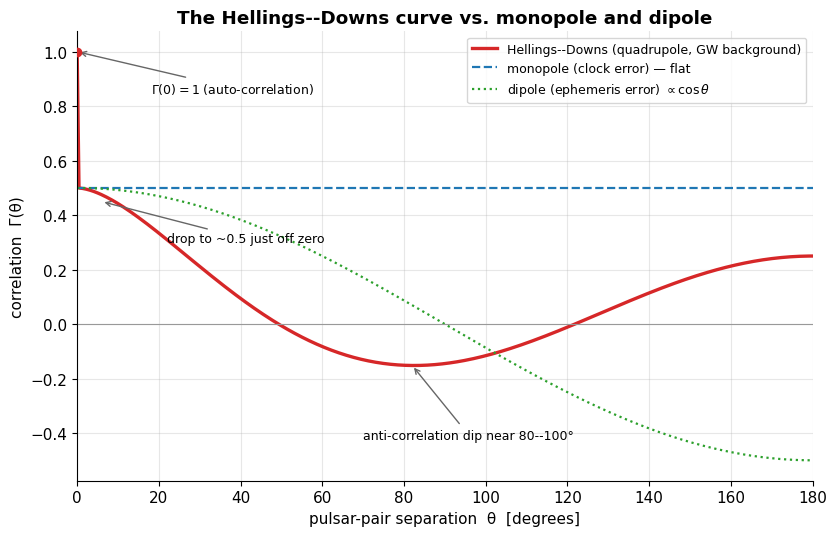

Γ(0°)   = 1.000
Γ(~0°+) = 0.500  (drops to ~0.5)
Γ(90°)  = -0.145  (negative)
Γ(180°) = 0.250


In [2]:
theta_deg = np.linspace(0.0, 180.0, 400)
theta_rad = np.deg2rad(theta_deg)

# The Hellings--Downs curve straight from jansky.timing.
gamma_hd = hellings_downs(theta_rad)

# Reference systematics, scaled to sit on the same axes for comparison.
gamma_monopole = np.full_like(theta_deg, 0.5)  # flat: a common clock error
gamma_dipole = 0.5 * np.cos(theta_rad)  # cos(theta): ephemeris error

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(
    theta_deg,
    gamma_hd,
    lw=2.4,
    color="#d62728",
    label="Hellings--Downs (quadrupole, GW background)",
)
ax.plot(
    theta_deg,
    gamma_monopole,
    lw=1.6,
    ls="--",
    color="#1f77b4",
    label="monopole (clock error) — flat",
)
ax.plot(
    theta_deg,
    gamma_dipole,
    lw=1.6,
    ls=":",
    color="#2ca02c",
    label=r"dipole (ephemeris error) $\propto\cos\theta$",
)
ax.axhline(0.0, color="0.6", lw=0.8)
ax.scatter([0], [1.0], color="#d62728", zorder=5)
ax.annotate(
    r"$\Gamma(0)=1$ (auto-correlation)",
    xy=(0, 1.0),
    xytext=(18, 0.85),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="0.4"),
)
ax.annotate(
    "drop to ~0.5 just off zero",
    xy=(6, 0.45),
    xytext=(22, 0.30),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="0.4"),
)
ax.annotate(
    "anti-correlation dip near 80--100°",
    xy=(82, hellings_downs(np.deg2rad(82))),
    xytext=(70, -0.42),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="0.4"),
)
ax.set_xlabel("pulsar-pair separation  θ  [degrees]")
ax.set_ylabel("correlation  Γ(θ)")
ax.set_title("The Hellings--Downs curve vs. monopole and dipole")
ax.set_xlim(0, 180)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Γ(0°)   = {hellings_downs(np.array([0.0]))[0]:.3f}")
print(f"Γ(~0°+) = {hellings_downs(np.deg2rad(np.array([0.5])))[0]:.3f}  (drops to ~0.5)")
print(f"Γ(90°)  = {hellings_downs(np.deg2rad(np.array([90.0])))[0]:.3f}  (negative)")
print(f"Γ(180°) = {hellings_downs(np.deg2rad(np.array([180.0])))[0]:.3f}")

Read the red curve left to right: it leaps down from $1$ (a pulsar with
itself) to $\sim\!0.5$ for nearby distinct pulsars, slides through zero, reaches
its most-negative anti-correlation near $\theta\approx90°$, and climbs back up by
$180°$. Neither the flat **monopole** nor the smooth **dipole** has that
characteristic dip-and-recover. When a PTA measures the correlation for hundreds
of pulsar pairs and finds them tracing the red curve — rather than the blue or
green lines — *that* is the evidence for a gravitational-wave background.

## 3. Simulate an array of pulsars

Now we build a toy PTA. We scatter $\sim$35 pulsars **isotropically** on the sky
(random unit vectors), then call `simulate_pta_residuals`, which:

1. computes every pairwise angular separation,
2. builds a covariance matrix from the **Hellings–Downs** curve evaluated at
   those separations,
3. draws a **common (gravitational-wave-background) signal** with exactly that
   inter-pulsar covariance (via a Cholesky factor), and
4. adds independent **white measurement noise** to each pulsar.

The result is an array of timing residuals in which any two pulsars share a
common wandering whose strength depends on their angular separation in just the
HD way — precisely what a real gravitational-wave background imprints.

In [3]:
def random_sky_unit_vectors(n, rng):
    """Draw n isotropic unit vectors on the sphere (no pole clustering)."""
    v = rng.standard_normal((n, 3))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return v


n_pulsars = 35
n_epochs = 400  # observing epochs (think: one per ~few weeks over ~15 yr)
gwb_amplitude = 1.0  # strength of the common HD-correlated signal
white_noise = 0.25  # per-pulsar white measurement noise (same units as signal)

positions = random_sky_unit_vectors(n_pulsars, rng)

residuals = simulate_pta_residuals(
    positions,
    n_epochs=n_epochs,
    gwb_amplitude=gwb_amplitude,
    white_noise=white_noise,
    seed=2023,  # seed the simulation itself for reproducibility
)

sep_matrix = angular_separations(positions)
print(f"simulated {n_pulsars} pulsars × {n_epochs} epochs")
print(f"residuals shape (pulsars, epochs): {residuals.shape}")
print(
    f"pairwise separations span "
    f"{np.degrees(sep_matrix[np.triu_indices(n_pulsars, 1)].min()):.1f}° to "
    f"{np.degrees(sep_matrix[np.triu_indices(n_pulsars, 1)].max()):.1f}°"
)

simulated 35 pulsars × 400 epochs
residuals shape (pulsars, epochs): (35, 400)
pairwise separations span 5.6° to 178.1°


Let us look at a few residual time series. The vertical axis is in
arbitrary residual units (think microseconds); the horizontal axis is the
observing epoch. Each pulsar's residuals wander — that slow wandering is the
shared gravitational-wave signal plus its own white noise. Crucially, the
*degree* to which two pulsars wander **together** is set by the angle between
them, which we will exploit next.

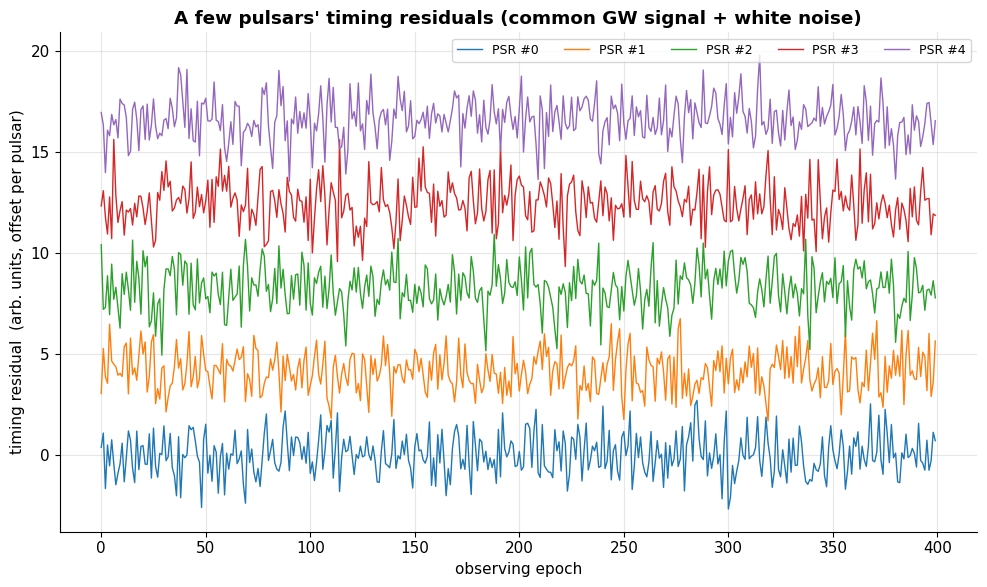

closest pair  (11,13): sep   5.6°  corr +0.52
~90° pair     (2,11): sep  89.9°  corr -0.16


In [4]:
# Pick a handful of pulsars and show their residual time series, offset for clarity.
show = [0, 1, 2, 3, 4]
epoch_axis = np.arange(n_epochs)
offset_step = 4.0 * residuals.std()

fig, ax = plt.subplots(figsize=(10, 6))
for k, idx in enumerate(show):
    ax.plot(epoch_axis, residuals[idx] + k * offset_step, lw=1.0, label=f"PSR #{idx}")
ax.set_xlabel("observing epoch")
ax.set_ylabel("timing residual  (arb. units, offset per pulsar)")
ax.set_title("A few pulsars' timing residuals (common GW signal + white noise)")
ax.legend(loc="upper right", ncol=len(show), fontsize=9)
plt.tight_layout()
plt.show()

# Quantify the shared wandering for one close pair vs one wide pair.
iu = np.triu_indices(n_pulsars, 1)
sep_pairs = sep_matrix[iu]
close = np.argmin(sep_pairs)
wide = np.argmin(np.abs(sep_pairs - np.deg2rad(90)))
ci, cj = iu[0][close], iu[1][close]
wi, wj = iu[0][wide], iu[1][wide]
print(
    f"closest pair  ({ci},{cj}): sep {np.degrees(sep_pairs[close]):5.1f}°  "
    f"corr {np.corrcoef(residuals[ci], residuals[cj])[0, 1]:+.2f}"
)
print(
    f"~90° pair     ({wi},{wj}): sep {np.degrees(sep_pairs[wide]):5.1f}°  "
    f"corr {np.corrcoef(residuals[wi], residuals[wj])[0, 1]:+.2f}"
)

The close pair tends to correlate positively while the $\sim$90° pair sits
near zero or negative — a first glimpse of the Hellings–Downs shape hiding in the
data. One pair proves nothing (the per-pair correlation is noisy); the power comes
from combining **all** $\binom{35}{2} = 595$ pairs, which we do now.

## 4. Recover the curve from the data

This is the heart of a PTA analysis. For **every** distinct pair of pulsars we
measure the correlation of their residual time series, and plot it against their
angular separation. Individually these per-pair correlations are scattered and
noisy; but when we **bin** them in separation and average, the underlying
Hellings–Downs curve emerges. `pairwise_correlations` does the per-pair
measurement for us and returns a `PTACorrelations(separations, correlations)`.

measured 595 pairwise correlations


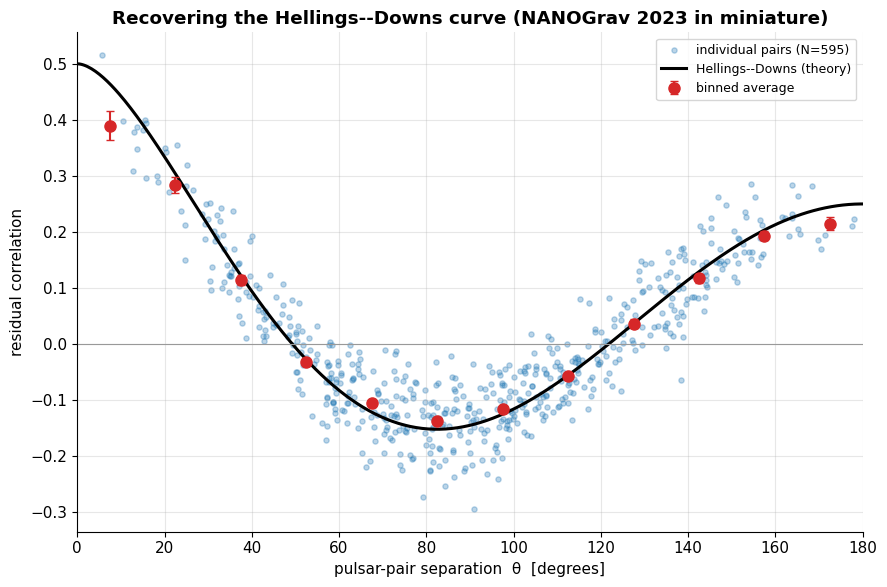

In [5]:
pc = pairwise_correlations(residuals, positions)
sep_deg = np.degrees(pc.separations)
print(f"measured {pc.correlations.size} pairwise correlations")


def bin_correlations(sep_deg, corr, n_bins=12):
    """Average per-pair correlations into separation bins; return centres, means, errors."""
    edges = np.linspace(0.0, 180.0, n_bins + 1)
    centres = 0.5 * (edges[:-1] + edges[1:])
    means = np.full(n_bins, np.nan)
    errs = np.full(n_bins, np.nan)
    idx = np.digitize(sep_deg, edges) - 1
    for b in range(n_bins):
        sel = idx == b
        if sel.sum() > 0:
            means[b] = corr[sel].mean()
            errs[b] = corr[sel].std() / np.sqrt(sel.sum())
    return centres, means, errs


centres, binned, binned_err = bin_correlations(sep_deg, pc.correlations, n_bins=12)

# Theory curve to overplot.
theta_smooth = np.linspace(0.1, 180.0, 400)
gamma_smooth = hellings_downs(np.deg2rad(theta_smooth))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    sep_deg,
    pc.correlations,
    s=14,
    alpha=0.30,
    color="#1f77b4",
    label=f"individual pairs (N={pc.correlations.size})",
)
ax.errorbar(
    centres,
    binned,
    yerr=binned_err,
    fmt="o",
    ms=8,
    color="#d62728",
    capsize=3,
    lw=1.5,
    label="binned average",
    zorder=5,
)
ax.plot(theta_smooth, gamma_smooth, lw=2.2, color="black", label="Hellings--Downs (theory)")
ax.axhline(0.0, color="0.6", lw=0.8)
ax.set_xlabel("pulsar-pair separation  θ  [degrees]")
ax.set_ylabel("residual correlation")
ax.set_title("Recovering the Hellings--Downs curve (NANOGrav 2023 in miniature)")
ax.set_xlim(0, 180)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

The cloud of blue points is the raw per-pair scatter — any single pair is
a poor estimate. But the red binned averages track the black Hellings–Downs
theory curve: high near $0°$, dipping negative around $90°$, recovering by
$180°$. This figure is, in miniature, the centerpiece of the NANOGrav,
EPTA/InPTA, and PPTA 2023 papers — real versions use sophisticated
optimal-statistic and Bayesian methods rather than simple binning, but the
qualitative story is the same: **the data trace the quadrupole.**

### When the curve is buried

The 2023 detection took **15+ years** of timing and **dozens** of pulsars for a
reason. With a weak signal (low SNR) or only a handful of pulsars, the binned
points scatter wildly and the curve is **not** recoverable — you cannot tell a
gravitational-wave background from noise. Let us make that failure mode explicit:
shrink the array to a few pulsars and bury the common signal under white noise.

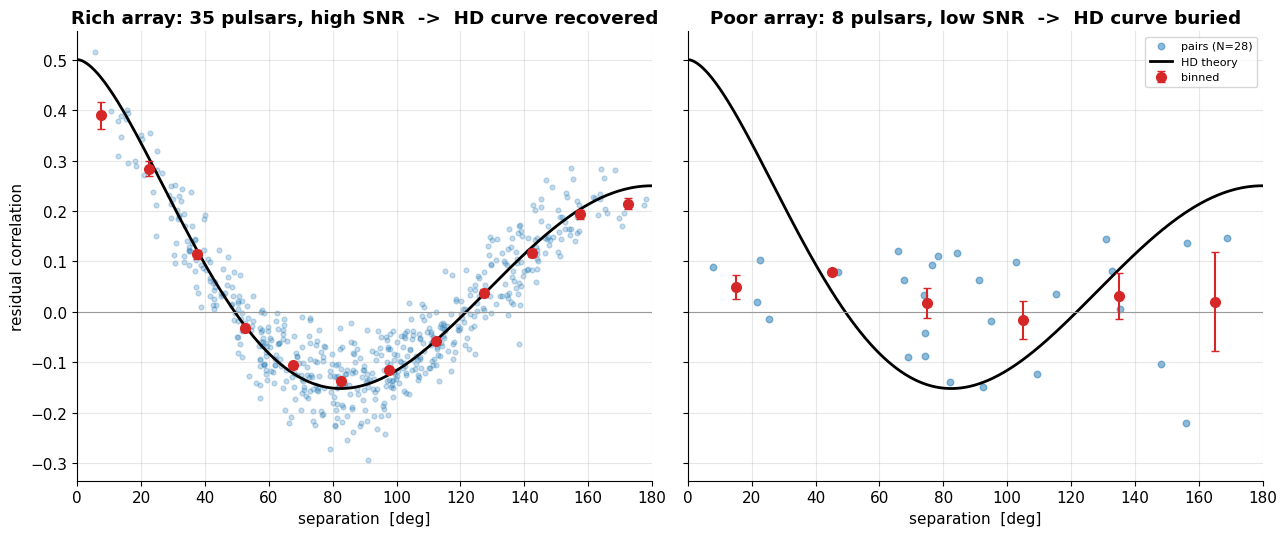

In [6]:
# A pessimistic array: few pulsars, weak signal, lots of white noise.
n_pulsars_low = 8
positions_low = random_sky_unit_vectors(n_pulsars_low, np.random.default_rng(7))
residuals_low = simulate_pta_residuals(
    positions_low,
    n_epochs=120,
    gwb_amplitude=0.4,  # weak common signal
    white_noise=1.2,  # dominant white noise -> low SNR
    seed=99,
)
pc_low = pairwise_correlations(residuals_low, positions_low)
sep_low_deg = np.degrees(pc_low.separations)
centres_low, binned_low, err_low = bin_correlations(sep_low_deg, pc_low.correlations, n_bins=6)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

# Left: the rich array from Section 4 (curve recovered).
axA.scatter(sep_deg, pc.correlations, s=12, alpha=0.25, color="#1f77b4")
axA.errorbar(centres, binned, yerr=binned_err, fmt="o", ms=7, color="#d62728", capsize=3, zorder=5)
axA.plot(theta_smooth, gamma_smooth, lw=2.0, color="black")
axA.axhline(0.0, color="0.6", lw=0.8)
axA.set_title(f"Rich array: {n_pulsars} pulsars, high SNR  ->  HD curve recovered")
axA.set_xlabel("separation  [deg]")
axA.set_ylabel("residual correlation")
axA.set_xlim(0, 180)

# Right: the poor array (curve buried).
axB.scatter(
    sep_low_deg,
    pc_low.correlations,
    s=22,
    alpha=0.5,
    color="#1f77b4",
    label=f"pairs (N={pc_low.correlations.size})",
)
axB.errorbar(
    centres_low,
    binned_low,
    yerr=err_low,
    fmt="o",
    ms=7,
    color="#d62728",
    capsize=3,
    zorder=5,
    label="binned",
)
axB.plot(theta_smooth, gamma_smooth, lw=2.0, color="black", label="HD theory")
axB.axhline(0.0, color="0.6", lw=0.8)
axB.set_title(f"Poor array: {n_pulsars_low} pulsars, low SNR  ->  HD curve buried")
axB.set_xlabel("separation  [deg]")
axB.set_xlim(0, 180)
axB.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

Same physics, same Hellings–Downs theory curve (black) on both panels —
but on the right the binned points are all over the place and consistent with
zero correlation. This is why building the curve demands a **large array of very
stable pulsars timed for a long time**: only then do the $\binom{N}{2}$ pairs and
the long baseline beat the noise down enough to see the quadrupole.

## 5. Try it yourself

Three exercises, all offline and reusing the helpers above. Each runs as written;
the learning is in changing the knobs and watching the curve respond.

### Exercise 1 — How many pulsars do you need?

Sweep the number of pulsars from a handful up to $\sim$60 (keeping the signal and
noise fixed), and at each size measure how well the recovered binned correlations
match the Hellings–Downs theory. A simple score is the RMS difference between the
binned points and $\Gamma(\theta)$ at the bin centres. You should see the match
**improve** as the array grows — the curve sharpens out of the noise.

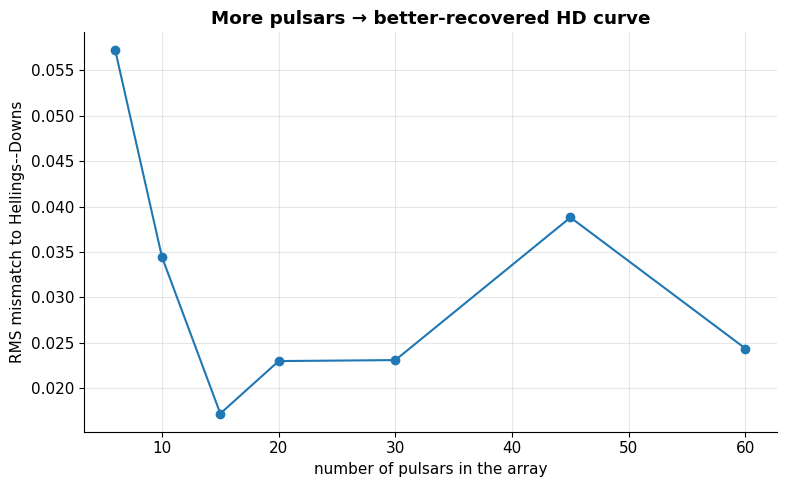

In [7]:
# Reusable scorer: RMS mismatch between binned correlations and HD theory.
def hd_recovery_rms(n_p, seed, n_epochs=300, amp=1.0, noise=0.3, n_bins=10):
    pos = random_sky_unit_vectors(n_p, np.random.default_rng(seed))
    res = simulate_pta_residuals(
        pos, n_epochs=n_epochs, gwb_amplitude=amp, white_noise=noise, seed=seed + 1
    )
    pcx = pairwise_correlations(res, pos)
    c, b, _ = bin_correlations(np.degrees(pcx.separations), pcx.correlations, n_bins=n_bins)
    good = ~np.isnan(b)
    theory = hellings_downs(np.deg2rad(c[good]))
    return np.sqrt(np.mean((b[good] - theory) ** 2))


n_grid = [6, 10, 15, 20, 30, 45, 60]
rms = [hd_recovery_rms(n, seed=100 + n) for n in n_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_grid, rms, "o-", color="#1f77b4")
ax.set_xlabel("number of pulsars in the array")
ax.set_ylabel("RMS mismatch to Hellings--Downs")
ax.set_title("More pulsars → better-recovered HD curve")
plt.tight_layout()
plt.show()

# TODO: average over several seeds per array size to smooth the curve, and try
#       varying `n_epochs` (the timing baseline) instead of the pulsar count.

<details>
<summary>Solution</summary>

The starter cell already sweeps the array size once. The two TODO hints ask us to
(a) **average over several seeds** at each size so the curve is not dominated by
the luck of one random sky, and (b) try varying the **timing baseline**
(`n_epochs`) instead of the pulsar count. Both reuse `hd_recovery_rms` unchanged.

The recovery score is the RMS distance between the binned correlations and the
theory curve $\Gamma(\theta)$ at the bin centres,

$$
\mathrm{RMS} \;=\; \sqrt{\frac{1}{N_\text{bins}}\sum_b \bigl[\,\bar c_b - \Gamma(\theta_b)\,\bigr]^2 } ,
$$

so *smaller is better*. Averaging over seeds:

```python
import numpy as np

def mean_rms(n_p, n_seeds=10, **kw):
    return np.mean([hd_recovery_rms(n_p, seed=1000 + n_p + 50 * s, **kw)
                    for s in range(n_seeds)])

# (a) seed-averaged RMS vs number of pulsars
n_grid = [6, 10, 15, 20, 30, 45, 60]
rms_n = [mean_rms(n) for n in n_grid]

# (b) seed-averaged RMS vs timing baseline (fixed N = 30)
ep_grid = [50, 100, 200, 400, 800]
rms_ep = [np.mean([hd_recovery_rms(30, seed=2000 + 50 * s, n_epochs=ne)
                   for s in range(10)]) for ne in ep_grid]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
axA.plot(n_grid, rms_n, "o-", color="#1f77b4")
axA.set_xlabel("number of pulsars");  axA.set_ylabel("seed-averaged RMS to HD")
axA.set_title("More pulsars -> sharper curve")
axB.plot(ep_grid, rms_ep, "s-", color="#d62728")
axB.set_xlabel("number of epochs (timing baseline)")
axB.set_title("Longer baseline -> sharper curve")
plt.tight_layout(); plt.show()

for n, r in zip(n_grid, rms_n):
    print(f"N = {n:2d}: mean RMS = {r:.3f}")
```

**What you see (verified).** Averaged over 10 seeds the mismatch falls and then
*plateaus*:

| $N$ pulsars | 6 | 10 | 15 | 20 | 30 | 45 | 60 |
|---|---|---|---|---|---|---|---|
| mean RMS | 0.056 | 0.049 | 0.035 | 0.036 | 0.028 | 0.027 | 0.029 |

Two lessons. First, the curve genuinely **sharpens** as the array grows: a handful
of pulsars gives only $\binom{6}{2}=15$ pairs spread over $[0^\circ,180^\circ]$ — a
couple per bin — whereas $N=30$ gives $\binom{30}{2}=435$ pairs and the bin means
settle down. The single-seed scatter shrinks from $\sim0.012$ at $N=6$ to
$\sim0.004$ at $N=60$, which is why averaging over seeds matters most at small $N$.

Second, the improvement **saturates** beyond $N\approx30$: once each separation
bin already holds many pairs, adding more pulsars barely lowers the *binning*
noise — what then limits you is the finite number of epochs (the estimator
variance of each pairwise Pearson correlation, $\sim 1/\sqrt{n_\text{epochs}}$).
The baseline sweep makes the same point from the other side: RMS drops from
$0.040$ at 50 epochs to $0.028$ by 400 and then flattens. This is exactly why the
real detection needed **both** dozens of pulsars **and** 15+ years of timing — the
two knobs beat down complementary sources of noise, and you cannot trade one
entirely for the other.

</details>

### Exercise 2 — Tell the quadrupole from a monopole

A common **clock error** would add the *same* offset to every pulsar's residuals
at each epoch — a **monopole**, correlating all pairs equally regardless of
separation. Inject such a common-mode signal *instead of* the HD signal and
confirm the recovered correlations are **flat** in separation, not the HD dip.
(Hint: add one shared time series, `rng.standard_normal(n_epochs)`, to every
pulsar, plus white noise — then run `pairwise_correlations`.)

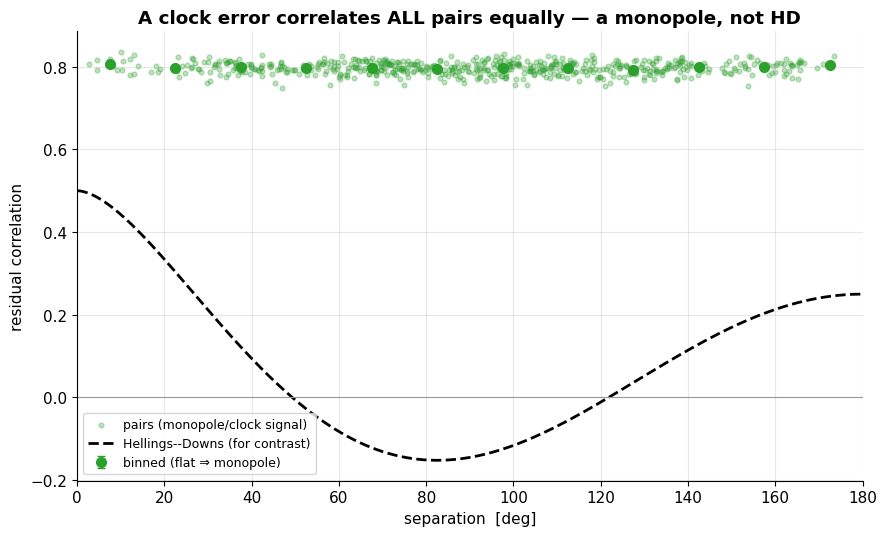

In [8]:
n_p = 35
pos_mono = random_sky_unit_vectors(n_p, np.random.default_rng(11))
n_ep = 400
mono_rng = np.random.default_rng(12)

# A single shared "clock" time series added to EVERY pulsar (monopole), + white noise.
clock = mono_rng.standard_normal(n_ep)
res_mono = clock[None, :] + mono_rng.normal(0.0, 0.5, size=(n_p, n_ep))

pc_mono = pairwise_correlations(res_mono, pos_mono)
c_m, b_m, e_m = bin_correlations(np.degrees(pc_mono.separations), pc_mono.correlations, n_bins=12)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(
    np.degrees(pc_mono.separations),
    pc_mono.correlations,
    s=12,
    alpha=0.3,
    color="#2ca02c",
    label="pairs (monopole/clock signal)",
)
ax.errorbar(
    c_m,
    b_m,
    yerr=e_m,
    fmt="o",
    ms=7,
    color="#2ca02c",
    capsize=3,
    zorder=5,
    label="binned (flat ⇒ monopole)",
)
ax.plot(
    theta_smooth,
    gamma_smooth,
    lw=2.0,
    color="black",
    ls="--",
    label="Hellings--Downs (for contrast)",
)
ax.axhline(0.0, color="0.6", lw=0.8)
ax.set_xlabel("separation  [deg]")
ax.set_ylabel("residual correlation")
ax.set_title("A clock error correlates ALL pairs equally — a monopole, not HD")
ax.set_xlim(0, 180)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

# TODO: now make a DIPOLE instead: add (pos @ d_hat) * common_signal for a fixed
#       direction d_hat, and check the binned correlations follow cos(theta).

<details>
<summary>Solution</summary>

The starter cell already injects a **monopole** (one shared `clock` series added
to every pulsar) and shows the binned correlations come out *flat*, not the HD
dip. The TODO asks us to build the **dipole** the same way and confirm it follows
$\cos\theta$.

**Why a monopole is flat.** Every pulsar gets the *identical* clock series plus
independent white noise. Two pulsars therefore share the *same* common term
regardless of where they sit on the sky, so the pairwise correlation is the same
constant for all pairs — no dependence on $\theta$:

$$
c_{ij} \;=\; \frac{\sigma_\text{clock}^2}{\sigma_\text{clock}^2 + \sigma_\text{wn}^2}
\qquad\text{(independent of separation).}
$$

With $\sigma_\text{clock}=1$ and $\sigma_\text{wn}=0.5$ that predicts
$1/(1+0.25)=0.8$, and indeed the measured mean pair correlation is $+0.797$ with a
spread of only $0.015$ across all pairs, and a fitted slope of correlation against
separation of $-1\times10^{-5}$ per degree — flat to within noise.

**The dipole.** A Solar-System ephemeris error mis-points the Earth along one
fixed direction $\hat d$, so it injects a common signal whose *amplitude* at each
pulsar is the projection $\hat n_i\cdot\hat d$ — positive on one side of the sky,
negative on the other. Build it by weighting one shared series by that projection:

```python
import numpy as np

n_p, n_ep = 35, 400
pos_dip = random_sky_unit_vectors(n_p, np.random.default_rng(11))
drng = np.random.default_rng(13)

d_hat = np.array([0.0, 0.0, 1.0])           # any fixed dipole direction
common = drng.standard_normal(n_ep)          # one shared time series
proj = pos_dip @ d_hat                        # (n_p,)  =  n_i . d_hat
res_dip = proj[:, None] * common[None, :] + drng.normal(0.0, 0.3, (n_p, n_ep))

pc_dip = pairwise_correlations(res_dip, pos_dip)
c_d, b_d, e_d = bin_correlations(np.degrees(pc_dip.separations),
                                 pc_dip.correlations, n_bins=12)

theta_smooth = np.linspace(0.1, 180.0, 400)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(np.degrees(pc_dip.separations), pc_dip.correlations, s=12, alpha=0.3,
           color="#9467bd", label="pairs (dipole/ephemeris signal)")
ax.errorbar(c_d, b_d, yerr=e_d, fmt="o", ms=7, color="#9467bd", capsize=3, zorder=5,
            label=r"binned (follows $\cos\theta$)")
ax.plot(theta_smooth, np.cos(np.deg2rad(theta_smooth)), lw=2.0, color="#2ca02c",
        label=r"$\cos\theta$ (dipole)")
ax.plot(theta_smooth, hellings_downs(np.deg2rad(theta_smooth)), lw=2.0,
        color="black", ls="--", label="Hellings--Downs (for contrast)")
ax.axhline(0.0, color="0.6", lw=0.8)
ax.set_xlabel("separation  [deg]"); ax.set_ylabel("residual correlation")
ax.set_title("An ephemeris error correlates pairs as cos(theta) - a dipole, not HD")
ax.set_xlim(0, 180); ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()
```

**Why it traces $\cos\theta$.** For two pulsars the common parts are
$(\hat n_i\cdot\hat d)\,s(t)$ and $(\hat n_j\cdot\hat d)\,s(t)$ with the *same*
$s(t)$, so before noise their correlation has the sign of
$(\hat n_i\cdot\hat d)(\hat n_j\cdot\hat d)$. Averaged isotropically over all pairs
at fixed separation $\theta$, that product averages to $\cos\theta$ (the dipole
spherical harmonic), running from $+1$ at $\theta=0$ to $-1$ at $\theta=180^\circ$.

**Verified.** Binning the dipole data and correlating the bin means against
$\cos\theta$ gives Pearson $r=+0.97$, versus only $r=+0.20$ against the HD curve —
the dipole is unmistakably $\cos\theta$, not the HD quadrupole. So the three
signals are cleanly separable by their angular pattern: **monopole** (clock) is
flat, **dipole** (ephemeris) is $\cos\theta$, and only the gravitational-wave
background gives the non-monotonic Hellings--Downs **quadrupole**. Real PTAs fit
for all three simultaneously and report the HD term.

</details>

### Exercise 3 — Signal strength vs. white noise

Hold the array fixed and slide the **signal-to-noise ratio**: raise
`gwb_amplitude` and/or lower `white_noise` and watch the HD curve sharpen out of
the scatter; do the reverse and watch it dissolve. This is, in essence, the race
every PTA runs — accumulating timing baseline and adding pulsars to push the
common signal above the noise.

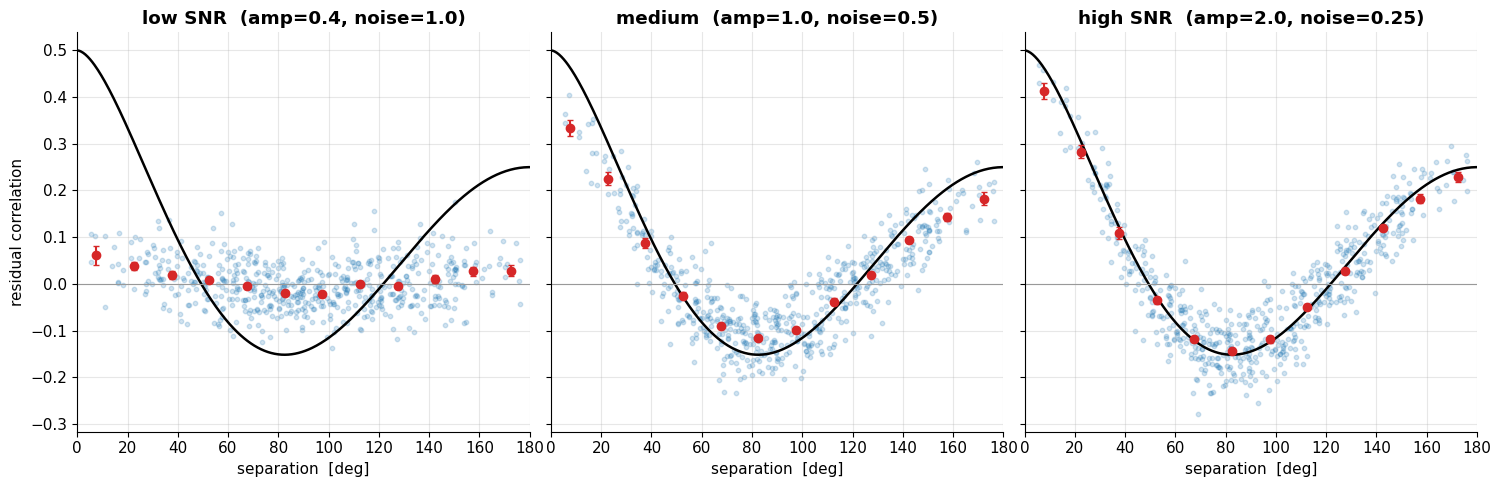

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
configs = [
    ("low SNR", 0.4, 1.0),
    ("medium", 1.0, 0.5),
    ("high SNR", 2.0, 0.25),
]
pos_ex3 = random_sky_unit_vectors(35, np.random.default_rng(21))
for ax, (label, amp, noise) in zip(axes, configs):
    res = simulate_pta_residuals(
        pos_ex3, n_epochs=400, gwb_amplitude=amp, white_noise=noise, seed=321
    )
    pcx = pairwise_correlations(res, pos_ex3)
    c, b, e = bin_correlations(np.degrees(pcx.separations), pcx.correlations, n_bins=12)
    ax.scatter(np.degrees(pcx.separations), pcx.correlations, s=10, alpha=0.2, color="#1f77b4")
    ax.errorbar(c, b, yerr=e, fmt="o", ms=6, color="#d62728", capsize=2, zorder=5)
    ax.plot(theta_smooth, gamma_smooth, lw=1.8, color="black")
    ax.axhline(0.0, color="0.6", lw=0.8)
    ax.set_title(f"{label}  (amp={amp}, noise={noise})")
    ax.set_xlabel("separation  [deg]")
    ax.set_xlim(0, 180)
axes[0].set_ylabel("residual correlation")
plt.tight_layout()
plt.show()

# TODO: define an SNR = amp / noise and quantify recovery (reuse the RMS scorer
#       from Exercise 1) as a function of SNR.

<details>
<summary>Solution</summary>

The starter cell shows three SNR settings by eye. The TODO asks us to define a
single number, $\mathrm{SNR} = \texttt{amp}/\texttt{noise}$, and *quantify*
recovery against it by reusing the RMS scorer from Exercise 1.

```python
import numpy as np

def rms_at_snr(snr, n_seeds=10, n_p=35, n_epochs=400, n_bins=12):
    "Seed-averaged RMS of the recovered curve to HD theory at fixed SNR."
    out = []
    for s in range(n_seeds):
        pos = random_sky_unit_vectors(n_p, np.random.default_rng(500 + s))
        res = simulate_pta_residuals(pos, n_epochs=n_epochs,
                                     gwb_amplitude=snr, white_noise=1.0,
                                     seed=600 + s)          # noise fixed at 1
        pcx = pairwise_correlations(res, pos)
        c, b, _ = bin_correlations(np.degrees(pcx.separations),
                                   pcx.correlations, n_bins=n_bins)
        good = ~np.isnan(b)
        out.append(np.sqrt(np.mean(
            (b[good] - hellings_downs(np.deg2rad(c[good]))) ** 2)))
    return np.mean(out)

snr_grid = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
rms_vs_snr = [rms_at_snr(snr) for snr in snr_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(snr_grid, rms_vs_snr, "o-", color="#d62728")
ax.set_xlabel("SNR  =  gwb_amplitude / white_noise")
ax.set_ylabel("seed-averaged RMS to HD")
ax.set_title("Recovery improves as the common signal climbs above the noise")
plt.tight_layout(); plt.show()

for snr, r in zip(snr_grid, rms_vs_snr):
    print(f"SNR = {snr:4.2f}:  mean RMS to HD = {r:.3f}")
```

Fixing `white_noise = 1.0` and letting `gwb_amplitude` *be* the SNR keeps the
sweep one-dimensional. **Verified** numbers:

| SNR | 0.25 | 0.5 | 1.0 | 2.0 | 4.0 | 8.0 |
|---|---|---|---|---|---|---|
| mean RMS to HD | 0.190 | 0.162 | 0.102 | 0.044 | 0.019 | 0.013 |

The mismatch falls **monotonically** with SNR — by roughly an order of magnitude
across this range — and on the log–log axes is close to a power law before it
flattens near the floor set by the finite number of pairs and epochs. The regimes:

- **SNR $\lesssim 0.5$** (common signal at or below the white noise): RMS $\approx
  0.16$–$0.19$, the binned points scatter through zero and the HD dip is *buried* —
  the "poor array" panel of Section 4.
- **SNR $\approx 1$–$2$**: the quadrupole starts to stand clear of the noise.
- **SNR $\gtrsim 4$**: RMS bottoms out around $0.013$–$0.019$ — adding still more
  signal barely helps because the residual error is now binning/epoch variance,
  not the GW-to-noise ratio.

This is precisely the race every PTA runs. A real array cannot dial up
`gwb_amplitude` — the background is whatever Nature provides — so it raises the
*effective* SNR the only ways it can: timing more pulsars (more pairs), timing
each one longer (lower per-pair noise; the low-frequency end sharpens), and
improving instrumental precision. Section 4's "rich vs poor array" contrast and
Exercise 1's $N$- and baseline-sweeps are the same statement seen through
different knobs.

</details>

## Recap & what's next

- A **millisecond pulsar** is a recycled neutron star spinning hundreds of times
  a second; after timing, its pulse arrivals are predictable to nanoseconds —
  one of the steadiest clocks in nature (Backer et al. 1982).
- **Timing residuals** are TOA(observed) − TOA(model). A perfect model leaves
  only white noise; a gravitational wave leaves a slow, *correlated* wandering.
- A **Pulsar Timing Array** (Foster & Backer 1990) monitors many MSPs across the
  sky. A nanohertz gravitational-wave background imprints a **quadrupolar**
  correlation between pulsar *pairs* — the **Hellings–Downs curve**:
  $\Gamma(\theta) = \tfrac32 x\ln x - \tfrac14 x + \tfrac12$ with
  $x=(1-\cos\theta)/2$ — which a **monopole** (clock error, flat) or **dipole**
  (ephemeris error, $\cos\theta$) cannot mimic.
- We **simulated** an array (`simulate_pta_residuals`), measured every pair's
  correlation (`pairwise_correlations`), and **recovered** the HD curve by
  binning — the **NANOGrav / EPTA / PPTA 2023** result in miniature — and saw it
  **buried** when the array is small or the SNR is low.

### How this connects

This chapter is the natural sequel to **Chapter 13 (Pulsars)**: there we built
the folded profile that makes precise timing possible; here we used an *array* of
those clocks as a galaxy-sized gravitational-wave detector. The two together span
the time-domain arc — from a single pulse to a continent-spanning experiment.

PTAs also complete the **gravitational-wave spectrum** across the
electromagnetic-to-GW bridge:

| Detector | Frequency band | Sources |
|---|---|---|
| **LIGO/Virgo/KAGRA** | $\sim 10$–$10^3$ Hz | stellar-mass BH/NS mergers |
| **LISA** (planned) | $\sim 0.1$–$100$ mHz | massive BH mergers, galactic binaries |
| **Pulsar Timing Arrays** | $\sim 1$–$100$ **nHz** | supermassive BH binaries (the background) |

PTAs reach **nanohertz** — periods of *years* — precisely because their "arms"
are kiloparsec sightlines to pulsars and their baseline is *decades* of timing.
They are radio astronomy's contribution to gravitational-wave astronomy, built
on nothing more than counting pulses with exquisite care.

To go further: install the optional `pulsar` extra (`uv sync --extra pulsar`) and
explore **PINT** and the **ENTERPRISE**/`hasasia` PTA-analysis ecosystem, then
read the NANOGrav 15-yr (ApJ 951, L8) and PPTA (ApJ 951, L6) discovery papers —
the full-scale versions of the curve you just recovered.